# Continuous surrogate: point-cloud data, coordinate decoder, autograd physics

Exploratory notebook for the continuous-in-space-and-time surrogate
(`docs/continuous_surrogate_design.md`): `data/generate_dataset.py`'s
point-cloud `.npz` schema, `neural/coordinate_decoder.py`'s
`ContinuousThrombusSurrogate` (`CoordinateDecoder` head on the shared
FNO trunk), `mechanistic/geometry_sdf.py`'s analytic signed-distance
function, and `neural/physics_losses.py`'s autograd mass-conservation
residual. See `README.md` "The coordinate-decoder design" for the
prose version of all of this; this notebook is the runnable
illustration.

This notebook covers:

- Generating one point-cloud sample and plotting its raw mesh-node
  scatter directly -- no rasterization step, unlike notebook 1's
  `tripcolor`/`imshow` plots.
- Quickly training a small `ContinuousThrombusSurrogate` (a handful of
  epochs on 2 tiny samples -- enough to demonstrate the mechanics, not
  an accuracy benchmark) and querying it on a genuinely arbitrary grid
  of `(x, y)` points, at several different times, via
  `viz/rasterize_continuous.rasterize_continuous_model`.
- Plotting the analytic SDF over that same grid as a sanity check
  against the visible mesh boundary from the first plot.
- A concrete illustration of the autograd physics residual: real
  `torch.autograd.grad` calls on the model's own output at a handful of
  query points, contrasted with notebook 1's mechanistic-solver
  quantities (which are computed by direct FEM assembly, not
  differentiating a trained model) and with the grid-projection path's
  finite-difference physics loss (`neural/physics_losses.py`'s
  `mass_conservation_penalty`, evaluated on raster cells -- see that
  module's docstring; not otherwise shown in either notebook).

Deliberately out of scope: the mechanistic solver itself (mesh
generation, flow solve, transient coupling -- see notebook 1) and the
full training/benchmark pipeline (`thrombus-generate-dataset` ->
`thrombus-train --continuous` -> `thrombus-benchmark --continuous`,
`configs/continuous.yaml` -- see `README.md` "Run the continuous-
surrogate pipeline"). Everything below uses toy-small settings (a
couple of samples, a handful of epochs) purely to keep this notebook
fast and self-contained.

**Species excluded from training by default:** `conc_T`, `conc_PT`,
`conc_FI` (thrombin, prothrombin, fibrin) are zero-weighted in
`train_continuous`'s data loss by default
(`data.excluded_temporal_channels`, `neural/train.py`'s
`DEFAULT_EXCLUDED_TEMPORAL_CHANNELS`) -- checking actual QC data found
the mechanistic solver's concentration-cap safety clip binds for all
three in 100% of sampled runs, so their values are not physically
trustworthy without further recalibration. See `README.md` "Known
limitations" (the thrombin/fibrin entry) for the full explanation; this
notebook still loads/predicts them (they show up in `FIELD_NAMES`) but
does not treat their values as meaningful.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

from thrombus_bench.data.dataset import FIELD_NAMES, log_to_field
from thrombus_bench.data.generate_dataset import PARAM_ORDER, _run_one_sample
from thrombus_bench.data.sampler import ParameterSpace, normalize_params
from thrombus_bench.mechanistic.mesh import GeometryConfig
from thrombus_bench.mechanistic.geometry_sdf import signed_distance_to_wall
from thrombus_bench.neural.coordinate_decoder import ContinuousThrombusSurrogate
from thrombus_bench.neural.physics_losses import (
    continuous_mass_conservation_loss,
    sample_collocation_points,
)
from thrombus_bench.neural.train import train_continuous
from thrombus_bench.viz.rasterize_continuous import rasterize_continuous_model

with open("../configs/physio_params.yaml") as f:
    physio = yaml.safe_load(f)

GEOM_7MM = dict(aneurysm_diameter_mm=7.0, vessel_diameter_mm=3.2)

## Generate one point-cloud sample

Same 7 mm-diameter geometry as notebook 1, run briefly
(`end_time_s=0.3`, `dt_s=0.1`) via `data/generate_dataset._run_one_sample`
-- the same function `thrombus-generate-dataset` calls per sample, with
`n_snapshots=3` so it saves multiple checkpoints (Phase 1/3's point-cloud
schema: mesh node coordinates + field values at every checkpoint, no
rasterization).

In [2]:
def make_sample(aneurysm_diameter_mm, vessel_diameter_mm, heparin_uM=2.0):
    return {
        "aneurysm_diameter_mm": aneurysm_diameter_mm, "vessel_diameter_mm": vessel_diameter_mm,
        "inlet_velocity_cm_s": 47.0, "platelet_conc_plt_ml": 3.5e8,
        "heparin_conc_uM": heparin_uM, "prothrombin_uM": 1.1,
        "antithrombin_uM": 2.844, "fibrinogen_uM": 7.0,
    }


mesh_cfg = {"target_num_elements": 200}

t0 = time.time()
sample_a = _run_one_sample(
    make_sample(**GEOM_7MM), physio, mesh_cfg, end_time_s=0.3, dt_s=0.1, grid_size=(8, 8), n_snapshots=3
)
n_nodes = sample_a["node_coords"].shape[0]
fields_shape = sample_a["fields"].shape
checkpoint_times = sample_a["time_s"]
reliable = sample_a["thrombin_fibrin_reliable"]
print(f"ran in {time.time() - t0:.1f}s")
print(f"node_coords: ({n_nodes}, 2), fields: {fields_shape}, time_s: {checkpoint_times}")
print(f"thrombin_fibrin_reliable: {reliable}")

ran in 0.6s
node_coords: (231, 2), fields: (2, 231, 11), time_s: [0.2 0.3]
thrombin_fibrin_reliable: False


## Raw mesh-node scatter (no rasterization)

The point-cloud equivalent of notebook 1's `tripcolor` velocity-magnitude
plot: every mesh node plotted directly at its own `(x, y)` coordinate,
colored by velocity magnitude at the final checkpoint. No triangulation,
no grid, no `griddata` interpolation -- these are exactly the values
`ContinuousThrombusSurrogate` trains against.

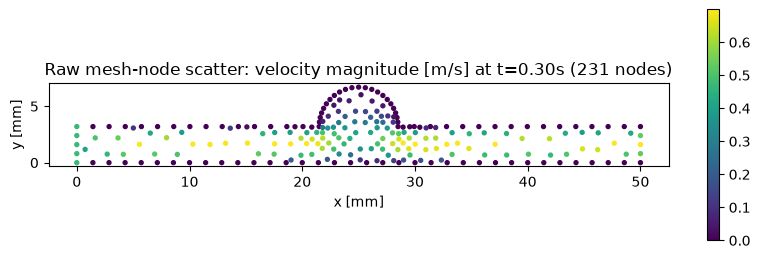

In [3]:
node_coords = sample_a["node_coords"]
final_fields = sample_a["fields"][-1]
final_time_s = sample_a["time_s"][-1]
speed = np.hypot(final_fields[:, FIELD_NAMES.index("velocity_x")], final_fields[:, FIELD_NAMES.index("velocity_y")])

fig, ax = plt.subplots(figsize=(10, 3))
sc = ax.scatter(node_coords[:, 0] * 1e3, node_coords[:, 1] * 1e3, c=speed, cmap="viridis", s=8)
ax.set_aspect("equal")
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_title(f"Raw mesh-node scatter: velocity magnitude [m/s] at t={final_time_s:.2f}s ({len(node_coords)} nodes)")
fig.colorbar(sc, ax=ax)
plt.show()

## Quickly train a small `ContinuousThrombusSurrogate`

A second, slightly different sample plus the first make up a 2-sample
"train" split; for this demo the same sample doubles as "val" too (not a
real train/val split -- just enough for `train_continuous` to run its
validation loop). A handful of epochs on a tiny architecture: this is
about exercising the training loop's mechanics, not producing an
accurate model -- see `README.md` "Run the continuous-surrogate
pipeline" for the real, config-driven training entry point.

In [4]:
import os
import tempfile

tmp_dir = tempfile.mkdtemp(prefix="continuous_surrogate_nb_")
os.makedirs(os.path.join(tmp_dir, "train"), exist_ok=True)
os.makedirs(os.path.join(tmp_dir, "val"), exist_ok=True)

sample_b = _run_one_sample(
    make_sample(8.0, 3.4), physio, mesh_cfg, end_time_s=0.3, dt_s=0.1, grid_size=(8, 8), n_snapshots=3
)
np.savez(os.path.join(tmp_dir, "train", "sample_0000.npz"), **sample_a)
np.savez(os.path.join(tmp_dir, "train", "sample_0001.npz"), **sample_b)
np.savez(os.path.join(tmp_dir, "val", "sample_0000.npz"), **sample_a)

train_cfg = {
    "seed": 0,
    "data": {"points_per_sample": None, "excluded_temporal_channels": ["conc_T", "conc_PT", "conc_FI"]},
    "model": {
        "encoder": {"param_dim": 9, "latent_grid_size": (8, 8), "hidden_channels": 8, "n_layers": 1},
        "operator_core": {"type": "fno", "fno": {"modes": 2, "hidden_channels": 8, "n_layers": 1}},
        "coordinate_encoding": {"num_frequency_bands": 6},
        "coordinate_decoder": {"mlp_hidden": 32, "n_residual_blocks": 1},
        "output_channels": 11,
        "uncertainty": {"mc_dropout_rate": 0.1},
    },
    "optim": {
        "epochs": 5, "batch_size": 2, "lr": 5.0e-3, "weight_decay": 0.0,
        "grad_clip_norm": 10.0, "early_stopping_patience": 1000,
    },
}

t0 = time.time()
checkpoint_path = os.path.join(tmp_dir, "model.pt")
final = train_continuous(train_cfg, tmp_dir, checkpoint_path, os.path.join(tmp_dir, "log.csv"))
print(f"trained in {time.time() - t0:.1f}s: {final}")

checkpoint = torch.load(checkpoint_path, weights_only=False)
model = ContinuousThrombusSurrogate(checkpoint["cfg"]).eval()
model.load_state_dict(checkpoint["model_state"])

trained in 0.7s: {'epoch': 4, 'train_loss': 78.46694946289062, 'val_loss': 75.59740447998047}


<All keys matched successfully>

## Query on an arbitrary grid, at several `t` -- continuity in space and time

`rasterize_continuous_model` (Phase 6) queries the trained model directly
on a regular grid over the analytic bounding box -- these grid points are
**not** mesh nodes (compare their positions to the scatter plot above);
the model was never trained at exactly these locations. Held-fixed
geometry/physiology, only the encoder's normalized-time input varies
across the three panels below.

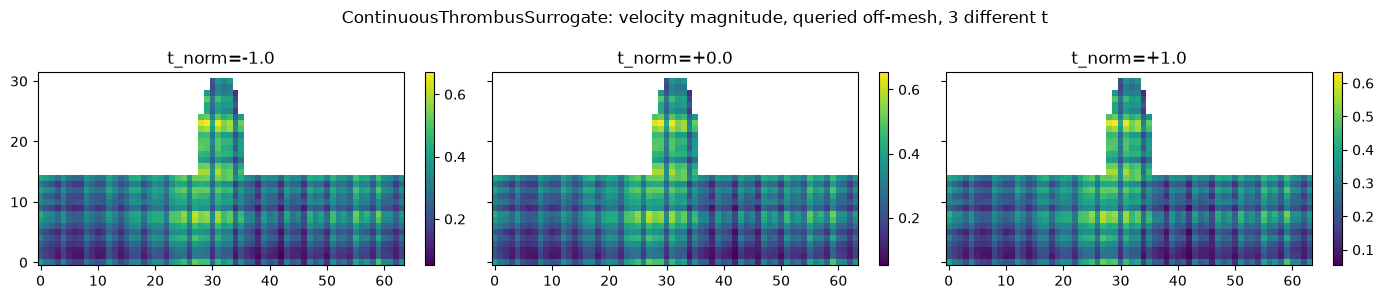

per-panel (min, max) speed: [(0.05122388154268265, 0.6715518236160278), (0.05191868543624878, 0.6544707417488098), (0.052961565554142, 0.6333556771278381)]


In [5]:
params_raw = np.array([make_sample(**GEOM_7MM)[name] for name in PARAM_ORDER])
params_norm = normalize_params(params_raw, ParameterSpace()).astype(np.float32)
geometry_mm = torch.tensor([GEOM_7MM["aneurysm_diameter_mm"], GEOM_7MM["vessel_diameter_mm"]])

t_norms = [-1.0, 0.0, 1.0]
fig, axes = plt.subplots(1, len(t_norms), figsize=(14, 3), sharey=True)
grids = []
for ax, t_norm in zip(axes, t_norms):
    params_with_time = torch.from_numpy(np.concatenate([params_norm, [t_norm]]).astype(np.float32))
    fields_grid, fluid_mask = rasterize_continuous_model(model, params_with_time, geometry_mm, grid_size=(32, 64))
    speed_grid = np.hypot(fields_grid[..., 0], fields_grid[..., 1])
    grids.append(speed_grid)
    im = ax.imshow(speed_grid, origin="lower", cmap="viridis", aspect="auto")
    ax.set_title(f"t_norm={t_norm:+.1f}")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("ContinuousThrombusSurrogate: velocity magnitude, queried off-mesh, 3 different t")
plt.tight_layout()
plt.show()

speed_ranges = [(float(np.nanmin(g)), float(np.nanmax(g))) for g in grids]
print("per-panel (min, max) speed:", speed_ranges)

Space: each panel is smooth and continuously varying across the whole
grid, including the many points that are not (and were never) mesh
nodes -- there is no per-cell/per-triangle structure the way a raster
built from `griddata` on scattered mesh values would show. Time: the
three panels differ (see the printed min/max above) since `t_norm` is
the only input that changes between them -- the model is not simply
memorizing a single static field.

## Analytic SDF sanity check

`mechanistic/geometry_sdf.signed_distance_to_wall` (Phase 1), evaluated
on the exact same grid as above -- its zero-level-set (the boundary
between the two colors below) should visually line up with the domain
boundary implied by the scatter plot's node cloud earlier in this
notebook.

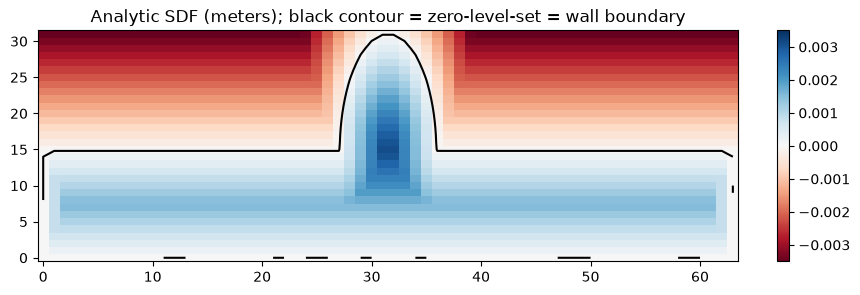

fraction of grid cells inside the domain (SDF >= 0): 0.523


In [6]:
L_m = 50.0 * 1e-3
D_m = GEOM_7MM["vessel_diameter_mm"] * 1e-3
R_m = GEOM_7MM["aneurysm_diameter_mm"] * 0.5e-3
geom = GeometryConfig(
    vessel_diameter_mm=GEOM_7MM["vessel_diameter_mm"],
    aneurysm_diameter_mm=GEOM_7MM["aneurysm_diameter_mm"],
    vessel_length_mm=50.0,
)

xs = np.linspace(0.0, L_m, 64)
ys = np.linspace(0.0, D_m + R_m, 32)
gx, gy = np.meshgrid(xs, ys)
sdf_grid = signed_distance_to_wall(gx.ravel(), gy.ravel(), geom).reshape(32, 64)

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(sdf_grid, origin="lower", cmap="RdBu", vmin=-np.abs(sdf_grid).max(), vmax=np.abs(sdf_grid).max(), aspect="auto")
ax.contour(sdf_grid, levels=[0.0], colors="black", linewidths=1.5)
ax.set_title("Analytic SDF (meters); black contour = zero-level-set = wall boundary")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

inside_fraction = (sdf_grid >= 0).mean()
print(f"fraction of grid cells inside the domain (SDF >= 0): {inside_fraction:.3f}")

## Autograd physics residual: true pointwise divergence

Notebook 1's mechanistic-solver quantities (wall shear rate, its axial
gradient, mass-conservation flux checks) are all computed by direct FEM
assembly/finite differences on the solver's own fields -- there is no
neural model to differentiate there. The grid-projection surrogate's
physics loss (`neural/physics_losses.mass_conservation_penalty`) is
*also* finite-difference-based, on raster cells. This is the third,
different mechanism: `mass_conservation_penalty_autograd` (via
`continuous_mass_conservation_loss`) calls `torch.autograd.grad`
directly on `ContinuousThrombusSurrogate`'s own output with respect to
its continuous `(x, y)` input -- an exact pointwise derivative of
whatever the model currently predicts, not an approximation on a grid.

This model is barely trained (5 epochs, 2 samples), so the residual
values themselves aren't physically meaningful yet -- the point here is
the mechanism, not the number.

In [7]:
params_with_time_batch = torch.from_numpy(np.concatenate([params_norm, [0.0]]).astype(np.float32)).unsqueeze(0)
geometry_mm_batch = geometry_mm.unsqueeze(0)

residual = continuous_mass_conservation_loss(
    model, params_with_time_batch, geometry_mm_batch, n_points_per_sample=12,
    vessel_length_mm=50.0, rng=np.random.default_rng(0),
)
print(f"mass-conservation residual, mean((du/dx + dv/dy)^2) over 12 collocation points: {residual.item():.3e}")

# Lower-level, to make the "true pointwise divergence via autograd" claim concrete:
# the same torch.autograd.grad call mass_conservation_penalty_autograd makes internally.
query_points_m, batch_index = sample_collocation_points(
    geometry_mm_batch, vessel_length_mm=50.0, n_points_per_sample=5, rng=np.random.default_rng(1)
)
points = query_points_m.detach().clone().requires_grad_(True)
pred = model(params_with_time_batch, points, batch_index, geometry_mm_batch)
u, v = log_to_field(pred[:, 0]), log_to_field(pred[:, 1])
du = torch.autograd.grad(u, points, grad_outputs=torch.ones_like(u), create_graph=True)[0]
dv = torch.autograd.grad(v, points, grad_outputs=torch.ones_like(v), create_graph=True)[0]
divergence = (du[:, 0] + dv[:, 1]).detach().numpy()

points_np = points.detach().numpy()
for (x, y), d in zip(points_np, divergence):
    x_mm, y_mm = x * 1e3, y * 1e3
    print(f"  (x={x_mm:6.2f}mm, y={y_mm:6.2f}mm) -> du/dx + dv/dy = {d:11.3f}")

mass-conservation residual, mean((du/dx + dv/dy)^2) over 12 collocation points: 1.826e+05
  (x= 25.59mm, y=  5.03mm) -> du/dx + dv/dy =    1438.721
  (x= 47.52mm, y=  1.88mm) -> du/dx + dv/dy =      82.563
  (x= 20.46mm, y=  1.86mm) -> du/dx + dv/dy =    -469.414
  (x= 27.48mm, y=  1.08mm) -> du/dx + dv/dy =    -717.973
  (x= 26.91mm, y=  0.78mm) -> du/dx + dv/dy =    -363.523
